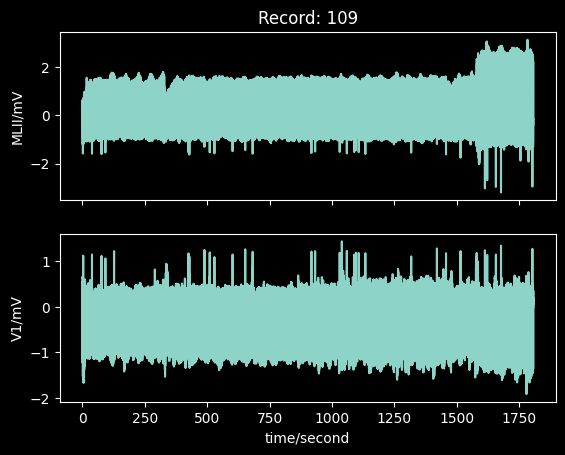

{'record_name': '109', 'n_sig': 2, 'fs': 360, 'counter_freq': None, 'base_counter': None, 'sig_len': 650000, 'base_time': None, 'base_date': None, 'comments': ['64 M 1508 694 x1', 'Quinidine', 'There is first degree AV block.  The PVCs are multiform.'], 'sig_name': ['MLII', 'V1'], 'p_signal': array([[ 0.175,  0.635],
       [ 0.175,  0.635],
       [ 0.175,  0.635],
       ...,
       [-0.92 ,  0.36 ],
       [-0.91 ,  0.365],
       [-1.28 ,  0.   ]], shape=(650000, 2)), 'd_signal': None, 'e_p_signal': None, 'e_d_signal': None, 'file_name': ['109.dat', '109.dat'], 'fmt': ['212', '212'], 'samps_per_frame': [1, 1], 'skew': [None, None], 'byte_offset': [None, None], 'adc_gain': [200.0, 200.0], 'baseline': [1024, 1024], 'units': ['mV', 'mV'], 'adc_res': [11, 11], 'adc_zero': [1024, 1024], 'init_value': [1059, 1151], 'checksum': [24085, 27089], 'block_size': [0, 0]}


In [2]:
import wfdb
import numpy as np
import pandas as pd
record_path='./mit-bih-arrhythmia-database-1.0.0/'
record = wfdb.rdrecord(record_path + '109')
wfdb.plot_wfdb(record=record)
print(record.__dict__)

In [3]:
ann = wfdb.rdann(record_path + '101', 'atr')
print(ann.__dict__)

{'record_name': '101', 'extension': 'atr', 'sample': array([     7,     83,    396, ..., 649004, 649372, 649751], shape=(1874,)), 'symbol': ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', '~', 'N', '|', 'N', 'N', 'N', 'N', '~', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N',

                            MLII     V1
0 days 00:00:00            0.175  0.635
0 days 00:00:00.002777777  0.175  0.635
0 days 00:00:00.005555554  0.175  0.635
0 days 00:00:00.008333331  0.175  0.635
0 days 00:00:00.011111108  0.175  0.635
...                          ...    ...
0 days 00:30:05.541161115 -0.900  0.355
0 days 00:30:05.543938892 -0.910  0.355
0 days 00:30:05.546716669 -0.920  0.360
0 days 00:30:05.549494446 -0.910  0.365
0 days 00:30:05.552272223 -1.280  0.000

[650000 rows x 2 columns]


,MLII,V1
count,650000.000000,650000.000000
mean,-0.230325,0.107461
std,0.499214,0.331964
min,-3.195000,-1.915000
25%,-0.520000,0.080000
50%,-0.275000,0.165000
75%,-0.100000,0.295000
max,3.130000,1.440000


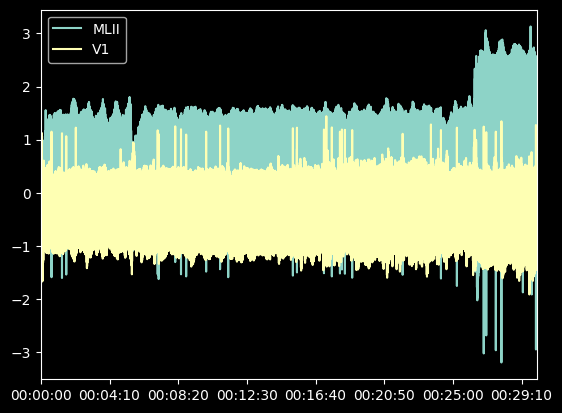

In [4]:
df = record.to_dataframe()
print(df)
df.plot()
df.describe()

In [119]:
# list all *.dat files in the directory
import os
case_nums = [f.split('.')[0] for f in os.listdir(record_path) if f.endswith('.dat')]
cases = {}
for num in case_nums:
    df = wfdb.rdrecord(record_path + num).to_dataframe()
    ann = wfdb.rdann(record_path + num, 'atr')
    cases[num] = {'signal': df, 'annotation': ann}

In [120]:
from scipy.signal import butter, filtfilt, find_peaks, resample

def resample_case(signal, fs, target_fs):
    num_samples = int(len(signal) * target_fs / fs)
    resampled_signal = resample(signal, num_samples)
    return resampled_signal

def filter_anns(ann_idx, ann_syms):
    # filter annotations to only include beat annotations
    beat_syms = {'N', 'L', 'R', 'B', 'A', 'a', 'S', 'J', 'V', 'r', 'F', 'e', 'j', 'n', 'E', '/', 'f', 'Q', '?'}
    filtered_idx = []
    filtered_syms = []
    for idx, sym in zip(ann_idx, ann_syms):
        if sym in beat_syms:
            filtered_idx.append(idx)
            filtered_syms.append(sym)
    return np.array(filtered_idx), np.array(filtered_syms)

def find_closest_symbol(idx, y_idx, y_syms):
    # find the closest annotation index to the given idx by binary search
    left, right = 0, len(y_idx) - 1
    while left <= right:
        mid = (left + right) // 2
        if y_idx[mid] < idx:
            left = mid + 1
        elif y_idx[mid] > idx:
            right = mid - 1
        else:
            return y_syms[mid]
    # If not found, return the symbol of the closest annotation
    if left >= len(y_idx):
        return y_syms[-1]
    if right < 0:
        return y_syms[0]
    if abs(y_idx[left] - idx) < abs(y_idx[right] - idx):
        return y_syms[left]
    else:
        return y_syms[right]

def preprocess_signal(x, fs, low=0.5, high=30):
    nyq = 0.5 * fs
    b, a = butter(3, [low/nyq, high/nyq], btype='band')
    signal = filtfilt(b, a, x)
    #signal = (signal - np.mean(signal)) / (np.std(signal) + 1e-8)
    signal = (signal - np.min(signal)) / (np.max(signal) - np.min(signal) + 1e-8)
    return signal

def extract_beats(x, y_idx, y_syms, fs, window_s = 10, threshold=0.85):
    beat_labels = []
    all_beats = []
    for i in range(0, len(x), fs * window_s):
        if i + fs * window_s > len(x):
            window = x[i:]
        else:
            window = x[i:i + fs * window_s]
        signal = preprocess_signal(window, fs)

        min_distance = int(0.2 * fs)  # 100 ms refractory period
        r_peaks, properties = find_peaks(
            signal,
            height=threshold,
            distance=min_distance
        )
        if len(r_peaks) < 2:
            continue
        # Median RR interval (nominal period T)
        rr_intervals = np.diff(r_peaks)
        T = int(np.median(rr_intervals))
        beat_length = int(0.8 * T)

        for peak in r_peaks:
            begin = peak - beat_length // 2
            end = peak + beat_length // 2
            if begin < 0:
                continue
            if end > len(signal):
                continue
            beat = signal[begin:end]
            beat = (beat - np.mean(beat)) / (np.std(beat) + 1e-8)
            all_beats.append(beat)
            ann = find_closest_symbol(peak+i, y_idx, y_syms)
            beat_labels.append(ann)

    # beat_labels.extend([y[i]] * len(beats))
    return all_beats, np.array(beat_labels)

In [121]:
lead = 'MLII'
skipped = 0
all_beats = []
all_labels = np.empty((0,))
orig_fs = 360
fs = 125
beat_length = int(fs * 1.5)
for num in case_nums:
    case = cases[num]
    if lead not in case['signal'].columns:
        skipped += 1
        continue
    signal = case['signal'][lead].values
    ann_idx = case['annotation'].sample
    ann_syms = case['annotation'].symbol
    ann_idx_filtered, ann_syms_filtered = filter_anns(ann_idx, ann_syms)
    ann_idx_resampled = (ann_idx_filtered * fs / orig_fs).astype(int)
    resampled_signal = resample_case(signal, orig_fs, fs)
    try:
        beats, labels = extract_beats(resampled_signal, ann_idx_resampled, ann_syms_filtered, fs=fs, threshold=0.8)
    except Exception as e:
        print(e)
        continue
    print(f'Case {num}: extracted {len(beats)} beats and {labels.shape} labels')
    all_beats.extend(beats)
    all_labels = np.concatenate((all_labels, labels), axis=0)

print(f'Skipped {skipped} cases without lead {lead}')
print(len(all_beats))
print(all_labels.shape)

Case 232: extracted 1411 beats and (1411,) labels
Case 230: extracted 1872 beats and (1872,) labels
Case 234: extracted 2590 beats and (2590,) labels
Case 122: extracted 2329 beats and (2329,) labels
Case 200: extracted 2138 beats and (2138,) labels
Case 107: extracted 2568 beats and (2568,) labels
Case 111: extracted 1330 beats and (1330,) labels
Case 109: extracted 2260 beats and (2260,) labels
Case 124: extracted 1401 beats and (1401,) labels
Case 221: extracted 2207 beats and (2207,) labels
Case 203: extracted 1851 beats and (1851,) labels
Case 118: extracted 2008 beats and (2008,) labels
Case 220: extracted 1892 beats and (1892,) labels
Case 228: extracted 933 beats and (933,) labels
Case 214: extracted 1879 beats and (1879,) labels
Case 209: extracted 2690 beats and (2690,) labels
Case 222: extracted 1008 beats and (1008,) labels
Case 205: extracted 2385 beats and (2385,) labels
Case 100: extracted 1598 beats and (1598,) labels
Case 114: extracted 1655 beats and (1655,) labels
Ca

Text(0.5, 1.0, 'N')

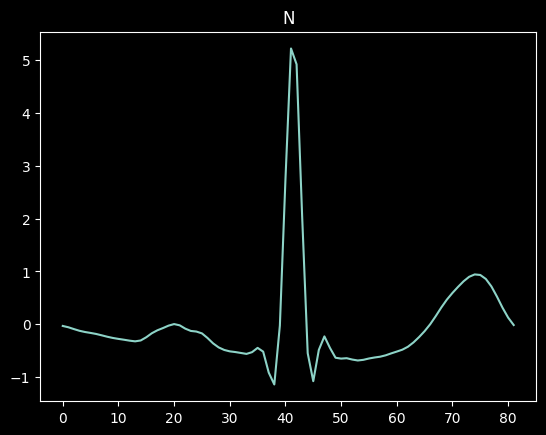

In [122]:
from matplotlib import pyplot as plt
case = 42000
plt.plot(all_beats[case])
plt.title(all_labels[case])

In [123]:
from collections import Counter
counter = Counter(all_labels)
print(counter)

Counter({np.str_('N'): 60950, np.str_('L'): 6713, np.str_('R'): 6406, np.str_('/'): 4169, np.str_('V'): 3787, np.str_('A'): 1998, np.str_('F'): 689, np.str_('E'): 146, np.str_('f'): 143, np.str_('j'): 123, np.str_('J'): 76, np.str_('a'): 17, np.str_('e'): 16, np.str_('Q'): 10})


In [124]:
# remap labels to 5 classes: N, S, V, F, Q
label_map = {
    'N': 'N',  # Normal beat
    'L': 'N',  # Left bundle branch block beat
    'R': 'N',  # Right bundle branch block beat
    'e': 'N',  # Atrial escape beat
    'j': 'N',  # Nodal (junctional) escape beat
    'A': 'S',  # Atrial premature beat
    'a': 'S',  # Aberrated atrial premature beat
    'S': 'S',  # Supraventricular premature beat (atrial or junctional)
    'J': 'S',  # Nodal (junctional) premature beat
    'V': 'V',  # Premature ventricular contraction
    'E': 'V',  # Ventricular escape beat
    'F': 'F',  # Fusion of ventricular and normal beat
    '/': 'Q',  # Paced beat
    'f': 'Q',  # Fusion of paced and normal beat
    'Q': 'Q',  # Unclassifiable beat
}
labels = np.array([label_map.get(label, 'Q') for label in all_labels])

In [125]:
# count class distribution
from collections import Counter
counter = Counter(labels)
print(counter)

Counter({np.str_('N'): 74208, np.str_('Q'): 4322, np.str_('V'): 3933, np.str_('S'): 2091, np.str_('F'): 689})


In [129]:
fixed_length = int(fs * 1.2)
pad_beats = np.zeros((len(all_beats), fixed_length))
for j, beat in enumerate(all_beats):
    length = min(len(beat), fixed_length)
    pad_beats[j, :length] = beat[:length]
pad_beats = np.array(pad_beats)
# all_beats = np.concatenate((all_beats, np.array(beats)), axis=0)


(85243, 150)
(85243,)


Text(0.5, 1.0, 'N')

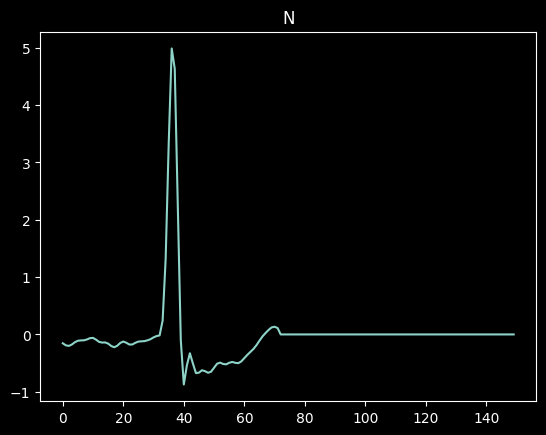

In [150]:
print(pad_beats.shape)
print(labels.shape)
case = 19000
plt.plot(pad_beats[case])
plt.title(labels[case])

In [132]:
np.save('mitbih_beats_x.npy', pad_beats)
np.save('mitbih_beats_y.npy', labels)